In [139]:
import mofr

In [140]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, time, timedelta
from SynthSpread.spreadviewer_class import SpreadSingle, SpreadViewerData, norm_coeff
#from Database.TPData import TPData, TPDataDa, TPDataAssembly

from Strategies.LeadLagRegression_strategy.backtest_class import BacktestLL
from Strategies.LeadLagRegression_strategy.strategy_class import StrategyLL, VolumeClass
from support_functions import calculate_MACD, calculate_lead_lag_triggers, calculate_regression_model_price
tol=(1e-1)/2

import seaborn as sns


In [141]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from xgboost import XGBClassifier, plot_tree
import xgboost as xgb
import shap
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.tree import export_text
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression

In [142]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [143]:
import warnings
warnings.filterwarnings('ignore')

In [144]:
max_secs_between_trades=60
cluster_trade_num_threshold=5
min_price_movement=0.05

burnout_period=30
stop_profit=0.3
makeagg_ratio=0.6

take_profit=0.5
stop_loss=-0.4

br_fee = 0.0175
closing_mode='Martinovo_zatvaranie'

In [145]:
##########################
param_dict = {}
param_dict['t_end'] = time(17)
param_dict['take_profit'] = take_profit
param_dict['stop_loss'] = stop_loss
param_dict['ba_max']=0.3

param_dict['burnout_period']=burnout_period
param_dict['stop_profit']=stop_profit
param_dict['makeagg_ratio']=makeagg_ratio

param_dict['br_fee'] = br_fee
##########################


strategy_class = StrategyLL(
                            strategy='LL',
                            market='de',
                            instrument='m2',
                            is_overnight=False,
                            closing_mode=closing_mode)

strategy_class.param_dict=param_dict

# Data preparation

In [146]:
data_lead = pd.read_csv(r's:\Algo\Files\andrej\Data\int_data_lead_ttf_may_june.csv',
                    parse_dates=['datetime']).reset_index()

data_lag = pd.read_csv(r's:\Algo\Files\andrej\Data\int_data_lag_deq1_oot_may_june.csv',
                    parse_dates=['datetime']).reset_index()

In [147]:
data_lead['datetime']=pd.to_datetime(data_lead['datetime'], format='mixed')
data_lag['datetime']=pd.to_datetime(data_lag['datetime'], format='mixed')

In [148]:
data_lag['time_diff']=data_lag['datetime'].diff().dt.total_seconds().fillna(0)

In [149]:
data_lead=data_lead[data_lead['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]
data_lag=data_lag[data_lag['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]

In [150]:
data_lag['date']=data_lag['datetime'].apply(lambda x: x.date())

In [151]:
data_lag=calculate_MACD(data_lag)
data_lag=calculate_lead_lag_triggers(data_lead, data_lag, max_secs_between_trades, cluster_trade_num_threshold, min_price_movement)
data_lag=calculate_regression_model_price(data_lead, data_lag, 10, 10, 5)

In [152]:
def calc_time_since_predicted_price(row):
    
        return (row['datetime']-row['lag_price_predicted_datetime']).total_seconds()
   

In [153]:
 data_lag['time_since_predicted_price']=data_lag[['datetime', 'lag_price_predicted_datetime']].apply(lambda row: calc_time_since_predicted_price(row), axis=1)

In [154]:
data_lag.head()

,index,datetime,trd_price,volume,bid_price,ask_price,mid_price,trd_side,time_diff,date,MACD,trigger_datetime,trigger_action,lag_price_predicted,lag_price_predicted_datetime,time_since_predicted_price
0,0,2024-05-01 09:05:49,NaN,NaN,70.0,NaN,70.0,1,0.0,2024-05-01,NaN,NaT,NaN,NaN,NaT,NaN
1,1,2024-05-01 09:05:50,NaN,NaN,70.0,NaN,70.0,1,1.0,2024-05-01,NaN,NaT,NaN,NaN,NaT,NaN
2,2,2024-05-01 09:05:51,NaN,NaN,70.0,NaN,70.0,1,1.0,2024-05-01,NaN,NaT,NaN,NaN,NaT,NaN
3,3,2024-05-01 09:05:52,NaN,NaN,70.0,NaN,70.0,1,1.0,2024-05-01,NaN,NaT,NaN,NaN,NaT,NaN
4,4,2024-05-01 09:05:53,NaN,NaN,70.0,NaN,70.0,1,1.0,2024-05-01,NaN,NaT,NaN,NaN,NaT,NaN


# Target Calculation

In [155]:
def calculate_close_slot_long(open_price, open_time, row):
    
        if row['ask_price']-row['bid_price']>param_dict['ba_max']:
            return (0,0)
    
        strategy_class = StrategyLL(
                            strategy='LL',
                            market='de',
                            instrument='m2',
                            is_overnight=False,
                            closing_mode=closing_mode)

        strategy_class.param_dict=param_dict
        
        strategy_class.timestamp_ = row['datetime']
        strategy_class.mid_p = row['mid_price']
        strategy_class.bid_p = row['bid_price']
        strategy_class.ask_p = row['ask_price']
        strategy_class.trd_p = row['trd_price']
        strategy_class.trd_s = row['trd_side']
        strategy_class.time_diff=row['time_diff']
        
        strategy_class.position_dict['open_price']=open_price
        strategy_class.position_dict['volume']=1
        strategy_class.position_dict['open_time']=open_time
        
        strategy_class._position=1
        
        return strategy_class.calculate_close_slot()
    
def calculate_close_slot_short(open_price, open_time, row):

        if row['ask_price']-row['bid_price']>param_dict['ba_max']:
            return (0,0)
        
        strategy_class = StrategyLL(
                            strategy='LL',
                            market='de',
                            instrument='m2',
                            is_overnight=False,
                            closing_mode=closing_mode)

        strategy_class.param_dict=param_dict
        
        strategy_class.timestamp_ = row['datetime']
        strategy_class.mid_p = row['mid_price']
        strategy_class.bid_p = row['bid_price']
        strategy_class.ask_p = row['ask_price']
        strategy_class.trd_p = row['trd_price']
        strategy_class.trd_s = row['trd_side']
        strategy_class.time_diff=row['time_diff']
        
        strategy_class.position_dict['open_price']=open_price
        strategy_class.position_dict['volume']=-1
        strategy_class.position_dict['open_time']=open_time
        
        strategy_class._position=-1
        
        return strategy_class.calculate_close_slot()

    
def calculate_profit_long(row, df):
    
    if row['ask_price']-row['bid_price']>param_dict['ba_max']:
        return None
    
    open_price=row['ask_price']
    open_time=row['datetime']
    
    filtered_df=df[(df['date']==row['date'])&(df['datetime']>row['datetime'])]
    
    for index, row in filtered_df.iterrows():
        price,vol = calculate_close_slot_long(open_price, open_time, row)
        
        if price!=0 and vol!=0:
            return price-open_price-2*param_dict['br_fee']
    
    return 0

def calculate_profit_short(row, df):
    
    if row['ask_price']-row['bid_price']>param_dict['ba_max']:
        return None
    
    open_price=row['bid_price']
    open_time=row['datetime']
    
    filtered_df=df[(df['date']==row['date'])&(df['datetime']>row['datetime'])]
    
    for index, row in filtered_df.iterrows():
        price,vol = calculate_close_slot_short(open_price, open_time, row)
        
        if price!=0 and vol!=0:
            return open_price-price-2*param_dict['br_fee']
    
    return 0

In [156]:
df_filtered=data_lag[data_lag['time_since_predicted_price']<data_lag['time_diff']]

In [157]:
for date in sorted(list(set(df_filtered.date))):
    print(date)
    a=data_lag[data_lag['date']==date]
    df_filtered.loc[df_filtered['date']==date, 'profit_long']=df_filtered.loc[df_filtered['date']==date][['datetime', 'date', 'bid_price', 'ask_price']].apply(lambda row: calculate_profit_long(row, a), axis=1)
    df_filtered.loc[df_filtered['date']==date, 'profit_short']=df_filtered.loc[df_filtered['date']==date][['datetime', 'date', 'bid_price', 'ask_price']].apply(lambda row: calculate_profit_short(row, a), axis=1)

2024-05-02
2024-05-03
2024-05-06
2024-05-07
2024-05-08
2024-05-09
2024-05-10
2024-05-13
2024-05-14
2024-05-15
2024-05-16
2024-05-17
2024-05-20
2024-05-21
2024-05-22
2024-05-23
2024-05-24
2024-05-27
2024-05-28
2024-05-29
2024-05-30
2024-05-31
2024-06-03
2024-06-04
2024-06-05
2024-06-06
2024-06-07
2024-06-10
2024-06-11
2024-06-12
2024-06-13
2024-06-14
2024-06-17
2024-06-18
2024-06-19
2024-06-20
2024-06-21
2024-06-24
2024-06-25
2024-06-26
2024-06-27
2024-06-28


In [158]:
df_filtered=df_filtered[df_filtered['datetime'].apply(lambda x: x.hour>8 and  x.hour<17)]
df_filtered=df_filtered[df_filtered['datetime'].apply(lambda x: x.day!=10 or x.month==3)]

In [159]:
df_filtered.to_csv(r's:\Algo\Files\andrej\Data\int_data_lag_dem1_mar_apr_enriched.csv')

# Model Calculation

In [160]:
seed=2

In [161]:
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from sklearn.metrics import r2_score

## Long model 

In [162]:
df_filtered['price_diff']=df_filtered['lag_price_predicted']-df_filtered['ask_price']

In [163]:
fil1=df_filtered['MACD'].isnull()==False
fil2=df_filtered['price_diff'].isnull()==False
fil3=df_filtered['trigger_action'].isnull()==False
fil4=df_filtered['profit_long'].isnull()==False

In [164]:
df_modelling=df_filtered[fil1&fil2&fil3&fil4]

### Regression

In [165]:
# Independent variable (lead_log_ret) and dependent variable (lag_log_ret)
X_train = df_modelling[['MACD', 'price_diff', 'trigger_action']]
y_train = df_modelling['profit_long'].fillna(0)

# Add a constant to the independent variable
X_train = sm.add_constant(X_train)

# Fit the model using statsmodels
model = sm.OLS(y_train, X_train).fit()

# Predict the lag_log_ret for the current day using the model
# X_test = sm.add_constant(df_trds_indexed.loc[df_trds_indexed['date']==current_day, 'lead_log_ret'].fillna(0))
# r_squared_test = r2_score(df_trds_indexed.loc[df_trds_indexed['date']==current_day, 'lag_log_ret'].fillna(0), model.predict(X_test).fillna(0))

# Optionally, print the summary for each model
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            profit_long   R-squared:                       0.011
Model:                            OLS   Adj. R-squared:                  0.010
Method:                 Least Squares   F-statistic:                     20.76
Date:                Tue, 06 Aug 2024   Prob (F-statistic):           2.26e-13
Time:                        13:32:03   Log-Likelihood:                -2645.5
No. Observations:                5669   AIC:                             5299.
Df Residuals:                    5665   BIC:                             5326.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -0.1506      0.006    -24.

### XGBoost

In [166]:
df_modelling['y']=(df_modelling['profit_long']>0).apply(int)
df_modelling['y'].value_counts()

y
0    3773
1    1896
Name: count, dtype: int64

In [167]:
feature_cols=['MACD', 'price_diff', 'trigger_action']

In [168]:
X_train, X_test, y_train, y_test = train_test_split(df_modelling[feature_cols], df_modelling['y'], test_size=0.25, random_state=seed)

xgb_model = XGBClassifier(max_depth=3, gamma=1, min_child_weight=5, n_estimators=5)
xgb_model.fit(X_train,
              y_train)
df_modelling['XGB_SCORE']=xgb_model.predict_proba(df_modelling[feature_cols])[:, 1]
X_train['XGB_SCORE']=xgb_model.predict_proba(X_train[feature_cols])[:, 1]
X_test['XGB_SCORE']=xgb_model.predict_proba(X_test[feature_cols])[:, 1]

preds_ = xgb_model.predict_proba(X_test[feature_cols])

In [169]:
print('The Lift on the df set is: '+ str(mofr.metrics.lift(y_train, X_train['XGB_SCORE'])))
print('The gini on the df set is: '+ str(mofr.metrics.gini(y_train, X_train['XGB_SCORE'])))
print('The accuracy on the df set is: '+ str(mofr.metrics.accuracy_score(y_train, X_train['XGB_SCORE'].apply(lambda x: int(x>0.5)))))
print('\n')
print('The Lift on the test set is: '+ str(mofr.metrics.lift(y_test, X_test['XGB_SCORE'])))
print('The gini on the test set is: '+ str(mofr.metrics.gini(y_test, X_test['XGB_SCORE'])))
print('The accuracy on the test set is: '+ str(mofr.metrics.accuracy_score(y_test, X_test['XGB_SCORE'].apply(lambda x: int(x>0.5)))))
print('\n')

The Lift on the df set is: 1.7760058315153546
The gini on the df set is: 0.31163498042029114
The accuracy on the df set is: 0.6847800517525288


The Lift on the test set is: 1.4511695906432749
The gini on the test set is: 0.21483653162757665
The accuracy on the test set is: 0.6622002820874471




In [170]:
result=[]
for feat in feature_cols:
    gini=mofr.metrics.gini(df_modelling['y'], df_modelling[feat])
    result.append((feat,gini))
    
pd.DataFrame(result)

,0,1
0,MACD,0.122275
1,price_diff,0.084149
2,trigger_action,0.017015


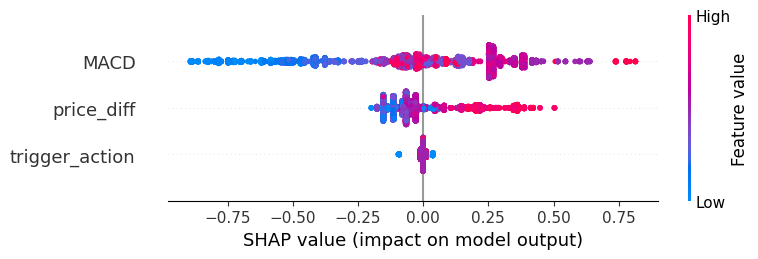

In [171]:
import shap
%matplotlib inline

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(df_modelling[feature_cols])
shap.summary_plot(shap_values, df_modelling[feature_cols])
plt.show()

#### **Precision curve**

In [172]:
preds_p = xgb_model.predict_proba(X_test[feature_cols])[:, 1]
#preds_p = model.predict(X_test).apply(lambda x: 1/(1+np.exp(-x)))

# threshold for more certainty in predicted values
thold_list = np.arange(0.2, 0.4, 0.001)
result = {'thold': [], 'precision': [], 'recall': [], 'count': []}
for thold in thold_list:
    preds = [1 if x > thold else 0 for x in preds_p]
    cm = confusion_matrix(y_test, preds)
    
    true_positives = cm[1, 1]  # Actual positive (1) and predicted positive (1)
    false_positives = cm[0, 1]  # Actual negative (0) but predicted positive (1)
    false_negatives = cm[1, 0]

    precision = true_positives / (true_positives + false_positives)
    recall = true_positives / (true_positives + false_negatives)
    result['thold'].append(thold)
    result['precision'].append(precision)
    result['recall'].append(recall)
    result['count'].append(true_positives + false_positives)
prec_recall_df = pd.DataFrame(result)

In [173]:
prec_recall_df[-50:]

,thold,precision,recall,count
150,0.350,0.424779,0.500000,565
151,0.351,0.424779,0.500000,565
152,0.352,0.424779,0.500000,565
153,0.353,0.424779,0.500000,565
154,0.354,0.424779,0.500000,565
155,0.355,0.424779,0.500000,565
156,0.356,0.455556,0.427083,450
157,0.357,0.455556,0.427083,450
158,0.358,0.455556,0.427083,450
159,0.359,0.455556,0.427083,450


### Interactions

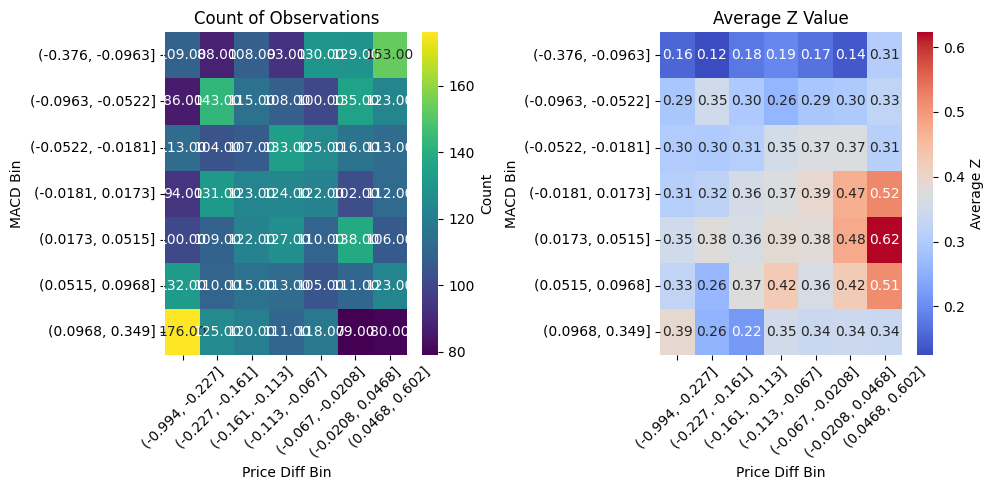

In [174]:
# Binning with interval labels
df_modelling.loc[:,'MACD_bin'] = pd.qcut(df_modelling['MACD'], 7, retbins=False, precision=3)
df_modelling.loc[:,'price_diff_bin'] = pd.qcut(df_modelling['price_diff'], 7, retbins=False, precision=3)


# Create pivot tables
count_pivot = df_modelling.pivot_table(index='MACD_bin', columns='price_diff_bin', values='y', aggfunc='count')
mean_pivot = df_modelling.pivot_table(index='MACD_bin', columns='price_diff_bin', values='y', aggfunc='mean')

# Setup figure for heatmaps
plt.figure(figsize=(10,5))

# Heatmap for count of observations
plt.subplot(1, 2, 1)
sns.heatmap(count_pivot, annot=True, fmt=".2f", cmap='viridis', cbar_kws={'label': 'Count'})
plt.title('Count of Observations')
plt.xlabel('Price Diff Bin')
plt.ylabel('MACD Bin')
plt.xticks(np.arange(len(count_pivot.columns)) + 0.5, count_pivot.columns, rotation=45)
plt.yticks(np.arange(len(count_pivot.index)) + 0.5, count_pivot.index, rotation=0)

# Heatmap for average of Z
plt.subplot(1, 2, 2)
sns.heatmap(mean_pivot, annot=True, fmt=".2f", cmap='coolwarm', cbar_kws={'label': 'Average Z'})
plt.title('Average Z Value')
plt.xlabel('Price Diff Bin')
plt.ylabel('MACD Bin')
plt.xticks(np.arange(len(mean_pivot.columns)) + 0.5, mean_pivot.columns, rotation=45)
plt.yticks(np.arange(len(mean_pivot.index)) + 0.5, mean_pivot.index, rotation=0)

plt.tight_layout()
plt.show()

In [175]:
count_pivot

price_diff_bin,"(-0.994, -0.227]","(-0.227, -0.161]","(-0.161, -0.113]","(-0.113, -0.067]","(-0.067, -0.0208]","(-0.0208, 0.0468]","(0.0468, 0.602]"
MACD_bin,,,,,,,
"(-0.376, -0.0963]",109,88,108,93,130,129,153
"(-0.0963, -0.0522]",86,143,115,108,100,135,123
"(-0.0522, -0.0181]",113,104,107,133,125,116,113
"(-0.0181, 0.0173]",94,131,123,124,122,102,112
"(0.0173, 0.0515]",100,109,122,127,110,138,106
"(0.0515, 0.0968]",132,110,115,113,105,111,123
"(0.0968, 0.349]",176,125,120,111,118,79,80


In [176]:
mean_pivot

price_diff_bin,"(-0.994, -0.227]","(-0.227, -0.161]","(-0.161, -0.113]","(-0.113, -0.067]","(-0.067, -0.0208]","(-0.0208, 0.0468]","(0.0468, 0.602]"
MACD_bin,,,,,,,
"(-0.376, -0.0963]",0.155963,0.125000,0.175926,0.193548,0.169231,0.139535,0.307190
"(-0.0963, -0.0522]",0.290698,0.349650,0.295652,0.259259,0.290000,0.296296,0.325203
"(-0.0522, -0.0181]",0.300885,0.298077,0.308411,0.353383,0.368000,0.370690,0.309735
"(-0.0181, 0.0173]",0.308511,0.320611,0.357724,0.370968,0.393443,0.470588,0.517857
"(0.0173, 0.0515]",0.350000,0.376147,0.360656,0.385827,0.381818,0.478261,0.622642
"(0.0515, 0.0968]",0.325758,0.263636,0.373913,0.424779,0.361905,0.423423,0.512195
"(0.0968, 0.349]",0.392045,0.256000,0.216667,0.351351,0.338983,0.341772,0.337500


## Short model 

In [177]:
df_filtered['price_diff']=df_filtered['lag_price_predicted']-df_filtered['bid_price']

In [178]:
fil1=df_filtered['MACD'].isnull()==False
fil2=df_filtered['price_diff'].isnull()==False
fil3=df_filtered['trigger_action'].isnull()==False
fil4=df_filtered['profit_long'].isnull()==False

In [179]:
df_modelling=df_filtered[fil1&fil2&fil3&fil4]

In [180]:
# Independent variable (lead_log_ret) and dependent variable (lag_log_ret)
X_train = df_modelling[['MACD', 'price_diff', 'trigger_action']]
y_train = df_modelling['profit_short'].fillna(0)

# Add a constant to the independent variable
X_train = sm.add_constant(X_train)

# Fit the model using statsmodels
model = sm.OLS(y_train, X_train).fit()

# Predict the lag_log_ret for the current day using the model
# X_test = sm.add_constant(df_trds_indexed.loc[df_trds_indexed['date']==current_day, 'lead_log_ret'].fillna(0))
# r_squared_test = r2_score(df_trds_indexed.loc[df_trds_indexed['date']==current_day, 'lag_log_ret'].fillna(0), model.predict(X_test).fillna(0))

# Optionally, print the summary for each model
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:           profit_short   R-squared:                       0.013
Model:                            OLS   Adj. R-squared:                  0.012
Method:                 Least Squares   F-statistic:                     24.67
Date:                Tue, 06 Aug 2024   Prob (F-statistic):           7.46e-16
Time:                        13:32:06   Log-Likelihood:                -2732.8
No. Observations:                5669   AIC:                             5474.
Df Residuals:                    5665   BIC:                             5500.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -0.1387      0.006    -23.

### XGBoost

In [181]:
df_modelling['y']=(df_modelling['profit_short']>0).apply(int)
df_modelling['y'].value_counts()

y
0    3636
1    2033
Name: count, dtype: int64

In [182]:
feature_cols=['MACD', 'price_diff', 'trigger_action']

In [183]:
X_train, X_test, y_train, y_test = train_test_split(df_modelling[feature_cols], df_modelling['y'], test_size=0.25, random_state=seed)

xgb_model = XGBClassifier(max_depth=3, gamma=1, min_child_weight=5, n_estimators=5)
xgb_model.fit(X_train,
              y_train)
df_modelling['XGB_SCORE']=xgb_model.predict_proba(df_modelling[feature_cols])[:, 1]
X_train['XGB_SCORE']=xgb_model.predict_proba(X_train[feature_cols])[:, 1]
X_test['XGB_SCORE']=xgb_model.predict_proba(X_test[feature_cols])[:, 1]

preds_ = xgb_model.predict_proba(X_test[feature_cols])

In [184]:
print('The Lift on the df set is: '+ str(mofr.metrics.lift(y_train, X_train['XGB_SCORE'])))
print('The gini on the df set is: '+ str(mofr.metrics.gini(y_train, X_train['XGB_SCORE'])))
print('The accuracy on the df set is: '+ str(mofr.metrics.accuracy_score(y_train, X_train['XGB_SCORE'].apply(lambda x: int(x>0.5)))))
print('\n')
print('The Lift on the test set is: '+ str(mofr.metrics.lift(y_test, X_test['XGB_SCORE'])))
print('The gini on the test set is: '+ str(mofr.metrics.gini(y_test, X_test['XGB_SCORE'])))
print('The accuracy on the test set is: '+ str(mofr.metrics.accuracy_score(y_test, X_test['XGB_SCORE'].apply(lambda x: int(x>0.5)))))
print('\n')

The Lift on the df set is: 1.7726416792130664
The gini on the df set is: 0.18264015465871908
The accuracy on the df set is: 0.6431427899317808


The Lift on the test set is: 1.5502915451895043
The gini on the test set is: 0.1698664513215935
The accuracy on the test set is: 0.6445698166431594




In [185]:
result=[]
for feat in feature_cols:
    gini=mofr.metrics.gini(df_modelling['y'], df_modelling[feat])
    result.append((feat,gini))
    
pd.DataFrame(result)

,0,1
0,MACD,-0.085432
1,price_diff,-0.075288
2,trigger_action,-0.016491


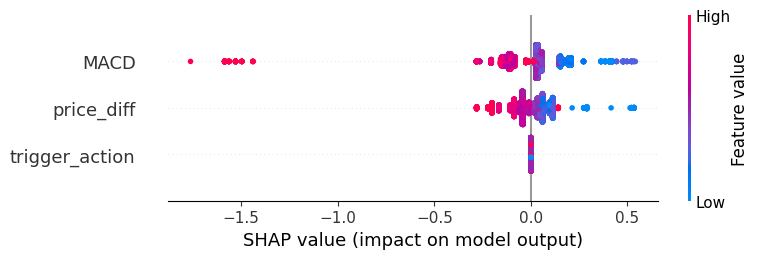

In [186]:
import shap
%matplotlib inline

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(df_modelling[feature_cols])
shap.summary_plot(shap_values, df_modelling[feature_cols])
plt.show()

#### **Precision curve**

In [187]:
preds_p = xgb_model.predict_proba(X_test[feature_cols])[:, 1]
#preds_p = model.predict(X_test).apply(lambda x: 1/(1+np.exp(-x)))

# threshold for more certainty in predicted values
thold_list = np.arange(0.2, 0.55, 0.001)
result = {'thold': [], 'precision': [], 'recall': [], 'count': []}
for thold in thold_list:
    preds = [1 if x > thold else 0 for x in preds_p]
    cm = confusion_matrix(y_test, preds)
    
    true_positives = cm[1, 1]  # Actual positive (1) and predicted positive (1)
    false_positives = cm[0, 1]  # Actual negative (0) but predicted positive (1)
    false_negatives = cm[1, 0]

    precision = true_positives / (true_positives + false_positives)
    recall = true_positives / (true_positives + false_negatives)
    result['thold'].append(thold)
    result['precision'].append(precision)
    result['recall'].append(recall)
    result['count'].append(true_positives + false_positives)
prec_recall_df = pd.DataFrame(result)

In [188]:
prec_recall_df[-50:]

,thold,precision,recall,count
300,0.500,0.500000,0.011905,12
301,0.501,0.500000,0.011905,12
302,0.502,0.500000,0.011905,12
303,0.503,0.500000,0.011905,12
304,0.504,0.500000,0.011905,12
305,0.505,0.500000,0.011905,12
306,0.506,0.500000,0.011905,12
307,0.507,0.500000,0.011905,12
308,0.508,0.500000,0.011905,12
309,0.509,0.500000,0.011905,12


### Interactions

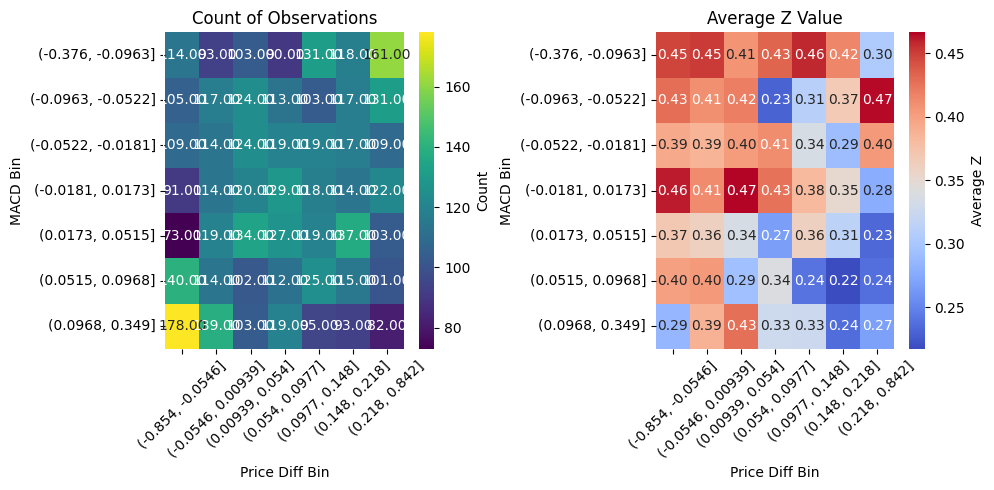

In [189]:
# Binning with interval labels
df_modelling.loc[:,'MACD_bin'] = pd.qcut(df_modelling['MACD'], 7, retbins=False, precision=3)
df_modelling.loc[:,'price_diff_bin'] = pd.qcut(df_modelling['price_diff'], 7, retbins=False, precision=3)


# Create pivot tables
count_pivot = df_modelling.pivot_table(index='MACD_bin', columns='price_diff_bin', values='y', aggfunc='count')
mean_pivot = df_modelling.pivot_table(index='MACD_bin', columns='price_diff_bin', values='y', aggfunc='mean')

# Setup figure for heatmaps
plt.figure(figsize=(10,5))

# Heatmap for count of observations
plt.subplot(1, 2, 1)
sns.heatmap(count_pivot, annot=True, fmt=".2f", cmap='viridis', cbar_kws={'label': 'Count'})
plt.title('Count of Observations')
plt.xlabel('Price Diff Bin')
plt.ylabel('MACD Bin')
plt.xticks(np.arange(len(count_pivot.columns)) + 0.5, count_pivot.columns, rotation=45)
plt.yticks(np.arange(len(count_pivot.index)) + 0.5, count_pivot.index, rotation=0)

# Heatmap for average of Z
plt.subplot(1, 2, 2)
sns.heatmap(mean_pivot, annot=True, fmt=".2f", cmap='coolwarm', cbar_kws={'label': 'Average Z'})
plt.title('Average Z Value')
plt.xlabel('Price Diff Bin')
plt.ylabel('MACD Bin')
plt.xticks(np.arange(len(mean_pivot.columns)) + 0.5, mean_pivot.columns, rotation=45)
plt.yticks(np.arange(len(mean_pivot.index)) + 0.5, mean_pivot.index, rotation=0)

plt.tight_layout()
plt.show()

In [190]:
count_pivot

price_diff_bin,"(-0.854, -0.0546]","(-0.0546, 0.00939]","(0.00939, 0.054]","(0.054, 0.0977]","(0.0977, 0.148]","(0.148, 0.218]","(0.218, 0.842]"
MACD_bin,,,,,,,
"(-0.376, -0.0963]",114,93,103,90,131,118,161
"(-0.0963, -0.0522]",105,117,124,113,103,117,131
"(-0.0522, -0.0181]",109,114,124,119,119,117,109
"(-0.0181, 0.0173]",91,114,120,129,118,114,122
"(0.0173, 0.0515]",73,119,134,127,119,137,103
"(0.0515, 0.0968]",140,114,102,112,125,115,101
"(0.0968, 0.349]",178,139,103,119,95,93,82


In [191]:
mean_pivot

price_diff_bin,"(-0.854, -0.0546]","(-0.0546, 0.00939]","(0.00939, 0.054]","(0.054, 0.0977]","(0.0977, 0.148]","(0.148, 0.218]","(0.218, 0.842]"
MACD_bin,,,,,,,
"(-0.376, -0.0963]",0.447368,0.451613,0.407767,0.433333,0.458015,0.415254,0.304348
"(-0.0963, -0.0522]",0.428571,0.410256,0.419355,0.230088,0.310680,0.367521,0.465649
"(-0.0522, -0.0181]",0.394495,0.385965,0.403226,0.411765,0.336134,0.290598,0.403670
"(-0.0181, 0.0173]",0.461538,0.412281,0.466667,0.426357,0.381356,0.350877,0.278689
"(0.0173, 0.0515]",0.369863,0.361345,0.335821,0.267717,0.361345,0.313869,0.233010
"(0.0515, 0.0968]",0.400000,0.403509,0.294118,0.339286,0.240000,0.217391,0.237624
"(0.0968, 0.349]",0.286517,0.388489,0.427184,0.327731,0.326316,0.236559,0.268293
